# Laboratory 1 — Conceptual Communication System & Signal-Flow Analysis

**Course:** ITAI-4370 · 5G Technologies &nbsp;|&nbsp; **Lab:** 1 &nbsp;|&nbsp; **Date:** June 8, 2026

**Topic:** Model a digital communication system as a block diagram, then implement and analyze its signal flow in Python (BPSK over an AWGN channel).

---

## Objectives
1. **Part 1 — Conceptual diagram:** represent a communication system as a chain of functional blocks
   `Source (Bits) → Modulator → Channel → Demodulator → Receiver (Bits)` using a free diagramming tool (Draw.io / Lucidchart), and export it as PNG/SVG.
2. **Part 2 — Signal-flow analysis:** implement that same chain in Python with **NumPy + Matplotlib**, using **BPSK** modulation over an **AWGN** channel, and quantify performance with bit errors, a constellation diagram, and a **BER vs Eb/N0** curve.

## Companion to *Work 1 — Telecommunications Fundamentals*
This lab is the hands-on counterpart to the written **Work 1**:
- Part 1 draws the **transmitter → channel → receiver** model discussed in Work 1 Q1–Q2.
- Part 2 implements the *"practical BPSK example"* explicitly referenced in Work 1 Q2 — *"the bits become pulses, the transmitter puts them on a carrier, the channel adds noise, and the receiver demodulates the signal to recover the message."*
- The **error rate** and **SNR** metrics from Work 1 Q3 appear here concretely as **BER** and **Eb/N0**.

## Deliverables in this folder
| File | Description |
|------|-------------|
| `Lab1_Communication_System.ipynb` | This notebook (markdown + code + embedded results) |
| `diagrams/communication_system.drawio` | Editable Draw.io block diagram (open at app.diagrams.net) |
| `diagrams/block_diagram.png` / `.svg` | Rendered block diagram for the report |
| `figures/signal_flow.png` | Time-domain signal at every stage of the chain |
| `figures/constellation.png` | Received BPSK constellation at two SNRs |
| `figures/ber_curve.png` | Simulated vs theoretical BER curve |

## Background — the digital communication chain

Every digital link, from a phone modem to a **5G NR** radio, can be drawn as the same sequence of blocks. In Work 1 these were grouped as **transmitter → channel → receiver**; here we expand the transmitter and receiver into their sub-blocks so the signal processing is explicit:

| Block | Grouped as | Role | In this lab |
|-------|-----------|------|-------------|
| **Source** | Transmitter | produces the information bits | random 0/1 bits |
| **Modulator** | Transmitter | maps bits onto a physical waveform | **BPSK**: 0→−1, 1→+1, times a cosine carrier |
| **Channel** | Channel | the physical medium; adds impairments | **AWGN** (additive white Gaussian noise) |
| **Demodulator** | Receiver | recovers symbols from the noisy waveform | multiply by carrier + integrate-and-dump |
| **Receiver** | Receiver | decides the output bits | threshold the decision statistic at 0 |

> **5G context:** 5G NR keeps exactly these blocks but uses higher-order modulation (QPSK / 16-, 64-, 256-QAM) carried on thousands of OFDM subcarriers. BPSK over AWGN is the textbook starting point that makes the signal flow easy to see, and its BER curve is the reference every other scheme is compared against.

In [1]:
# --- Setup: libraries, reproducible RNG, output folders, and plot styling ---
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy.special import erfc

rng = np.random.default_rng(42)          # fixed seed -> reproducible report

os.makedirs("diagrams", exist_ok=True)   # report-ready images are saved here
os.makedirs("figures",  exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
})
print("Environment ready — NumPy", np.__version__, "| Matplotlib", plt.matplotlib.__version__)

Environment ready — NumPy 2.1.3 | Matplotlib 3.10.0


---
# Part 1 — Conceptual Diagram (Draw.io / Lucidchart)

**Tool steps used to create `diagrams/communication_system.drawio`:**
1. Open **app.diagrams.net** (Draw.io) → *Create New Diagram* → *Blank*.
2. Drag a **rectangle** for each block, labelled left → right:
   `Source (Bits)` · `Modulator` · `Channel` · `Demodulator` · `Receiver (Bits)`.
3. Connect the blocks with **arrows** pointing left → right.
4. Add annotations: **"BPSK modulation"** under the modulator and a dashed **"Noise (AWGN)"** node feeding the channel ("noise added in channel").
5. *File → Export as → PNG / SVG* for the report.

The editable file is included at `diagrams/communication_system.drawio`. The cell below reproduces the **same diagram programmatically** with Matplotlib so it is embedded in this notebook and exported to `diagrams/block_diagram.png` and `.svg`.

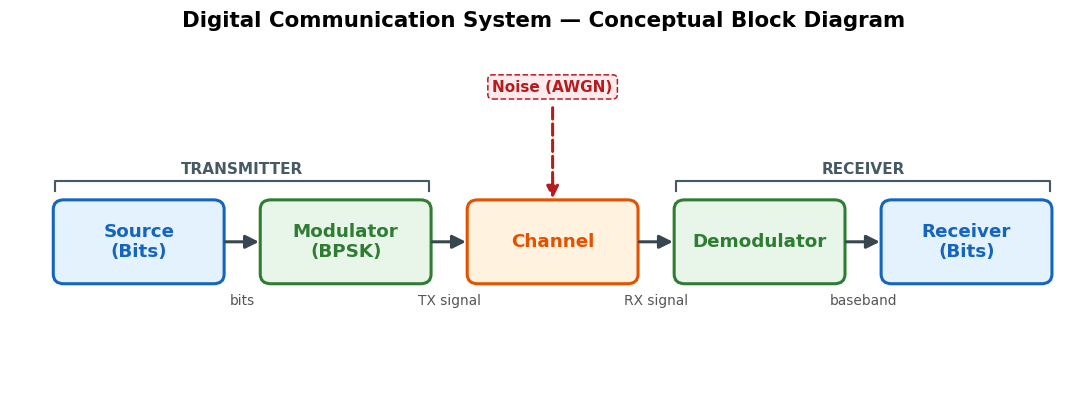

Saved -> diagrams/block_diagram.png and diagrams/block_diagram.svg


In [2]:
# --- Part 1: conceptual block diagram, drawn with Matplotlib and exported PNG/SVG ---
fig, ax = plt.subplots(figsize=(12.5, 4))
ax.set_xlim(-0.2, 11.9); ax.set_ylim(0, 4.2); ax.axis("off")

# (label, fill, edge)
blocks = [
    ("Source\n(Bits)",   "#E3F2FD", "#1565C0"),
    ("Modulator\n(BPSK)", "#E8F5E9", "#2E7D32"),
    ("Channel",          "#FFF3E0", "#E65100"),
    ("Demodulator",      "#E8F5E9", "#2E7D32"),
    ("Receiver\n(Bits)", "#E3F2FD", "#1565C0"),
]
w, h, yb = 1.9, 1.0, 1.3
xs = [0.3, 2.65, 5.0, 7.35, 9.7]

for (label, fc, ec), x in zip(blocks, xs):
    ax.add_patch(FancyBboxPatch((x, yb), w, h,
                 boxstyle="round,pad=0.02,rounding_size=0.12",
                 linewidth=2, edgecolor=ec, facecolor=fc))
    ax.text(x + w/2, yb + h/2, label, ha="center", va="center",
            fontsize=12, fontweight="bold", color=ec)

# left -> right arrows between consecutive blocks, with signal labels underneath
flow = ["bits", "TX signal", "RX signal", "baseband"]
for i in range(4):
    x_end, x_next = xs[i] + w, xs[i+1]
    ax.add_patch(FancyArrowPatch((x_end, yb + h/2), (x_next, yb + h/2),
                 arrowstyle="-|>", mutation_scale=18, linewidth=2, color="#37474F"))
    ax.text((x_end + x_next)/2, yb - 0.28, flow[i], ha="center", color="#555", fontsize=9)

# Noise (AWGN) source feeding the channel ("noise added in channel")
ncx = xs[2] + w/2
ax.text(ncx, 3.72, "Noise (AWGN)", ha="center", va="center",
        fontsize=10, fontweight="bold", color="#B71C1C",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFEBEE", ec="#B71C1C", ls="--"))
ax.add_patch(FancyArrowPatch((ncx, 3.5), (ncx, yb + h),
             arrowstyle="-|>", mutation_scale=16, linewidth=2, color="#B71C1C", ls="--"))

# Transmitter / Receiver grouping brackets (ties the 5 blocks to Work 1's 3-part model)
def bracket(x0, x1, label, color):
    y = 2.55
    ax.plot([x0, x0, x1, x1], [y - 0.12, y, y, y - 0.12], color=color, lw=1.4)
    ax.text((x0 + x1)/2, y + 0.06, label, ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=color)
bracket(xs[0], xs[1] + w, "TRANSMITTER", "#455A64")
bracket(xs[3], xs[4] + w, "RECEIVER",    "#455A64")

ax.set_title("Digital Communication System — Conceptual Block Diagram",
             fontsize=14, fontweight="bold", pad=14)

fig.savefig("diagrams/block_diagram.png", bbox_inches="tight")
fig.savefig("diagrams/block_diagram.svg", bbox_inches="tight")
plt.show()
print("Saved -> diagrams/block_diagram.png and diagrams/block_diagram.svg")

**Reading the diagram (left → right):** the **Source** emits bits; the **Modulator** turns each bit into a BPSK waveform (Source + Modulator = the *transmitter* of Work 1); the **Channel** corrupts it with additive noise — the red dashed arrow marks the *only* place the signal is degraded; the **Demodulator** and **Receiver** invert the process to recover the bits (= the *receiver* of Work 1). Part 2 implements this exact flow and shows the signal at every node.

---
# Part 2 — Signal-Flow Analysis in Python (NumPy + Matplotlib)

We now build the chain in code. The analysis has two layers:
- **Passband visualization** — small `N`, high samples/symbol — so the carrier and the BPSK phase flips are clearly visible in the time domain. This produces the *signal-flow* figure.
- **Baseband-equivalent Monte-Carlo** — large `N` — for statistically meaningful **constellation** and **BER** results. (For BPSK the passband and baseband models give identical BER, so the faster baseband model is used for statistics.)

### Simulation parameters

In [3]:
# --- Passband BPSK parameters (chosen so the waveforms are easy to read) ---
N         = 8     # number of information bits (small -> clear waveforms)
sps       = 50    # samples per symbol (high -> smooth carrier)
fc        = 2     # carrier cycles per bit (integer -> clean coherent demod)
noise_std = 0.5   # AWGN standard deviation added in the channel (time domain)

t = np.arange(0, N, 1/sps)            # time vector: each bit spans 1 time unit
print(f"{N} bits -> {len(t)} samples | {sps} samples/symbol | {fc} carrier cycles/bit")

8 bits -> 400 samples | 50 samples/symbol | 2 carrier cycles/bit


### Stages 1–5: build and process the signal
Each cell below is one block of the diagram.

In [4]:
# Stage 1 - SOURCE: random information bits, then BPSK symbol mapping (0 -> -1, 1 -> +1)
bits     = rng.integers(0, 2, N)
symbols  = 2*bits - 1                  # antipodal BPSK symbols
baseband = np.repeat(symbols, sps)     # hold each symbol for one symbol period
print("Source bits   :", bits)
print("BPSK symbols  :", symbols)

Source bits   : [0 1 1 0 0 1 0 1]
BPSK symbols  : [-1  1  1 -1 -1  1 -1  1]


In [5]:
# Stage 2 - MODULATOR: multiply the baseband by a cosine carrier (this IS BPSK)
carrier = np.cos(2*np.pi*fc*t)
tx      = baseband * carrier           # transmitted passband signal

In [6]:
# Stage 3 - CHANNEL: add white Gaussian noise (the only impairment)
noise = noise_std * rng.standard_normal(len(tx))
rx    = tx + noise                     # received signal

In [7]:
# Stage 4 - DEMODULATOR: coherent detection (multiply by the same carrier)...
demod = rx * carrier
# ...then matched filter / integrate-and-dump: average each symbol period -> ~ +/-1
decision = (2/sps) * demod.reshape(N, sps).sum(axis=1)

# Stage 5 - RECEIVER: threshold the decision statistic at 0 -> recovered bits
bits_hat = (decision > 0).astype(int)

errors  = int(np.sum(bits != bits_hat))
print("Original  bits :", bits)
print("Recovered bits :", bits_hat)
print("Decision stats :", np.round(decision, 2))
print(f"Bit errors: {errors}/{N}  (BER = {errors/N:.3f})  at noise_std = {noise_std}")

Original  bits : [0 1 1 0 0 1 0 1]
Recovered bits : [0 1 1 0 0 1 0 1]
Decision stats : [-1.07  1.05  0.85 -0.91 -0.98  1.01 -1.    1.03]
Bit errors: 0/8  (BER = 0.000)  at noise_std = 0.5


### Visualize the signal flow
The five stacked panels show the signal at each node of the chain. Dotted vertical lines mark symbol boundaries; the source bits are printed along the top.

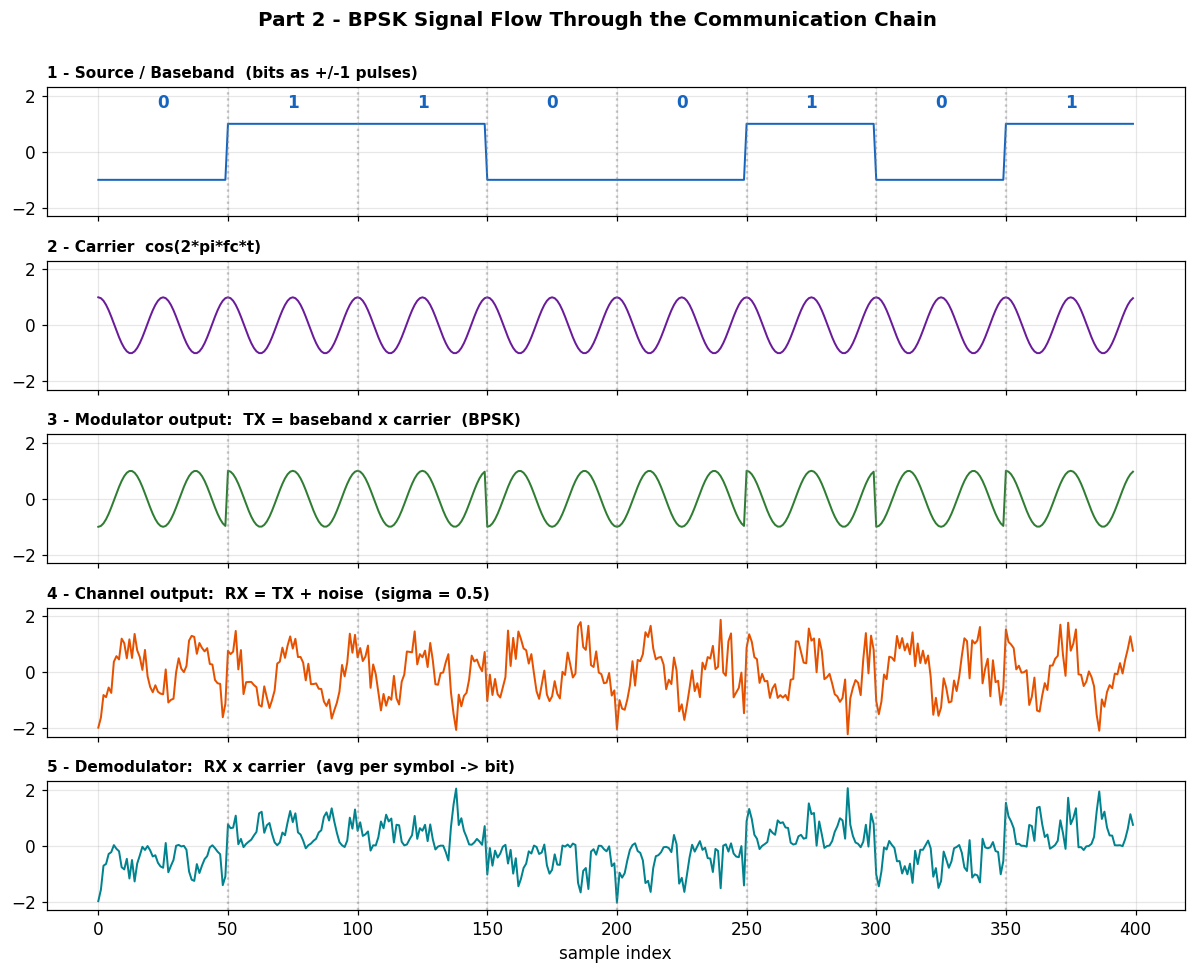

Saved -> figures/signal_flow.png


In [8]:
# --- Signal-flow figure: the signal at every stage of the chain ---
stages = [
    (baseband, "1 - Source / Baseband  (bits as +/-1 pulses)",            "#1565C0"),
    (carrier,  "2 - Carrier  cos(2*pi*fc*t)",                             "#6A1B9A"),
    (tx,       "3 - Modulator output:  TX = baseband x carrier  (BPSK)",  "#2E7D32"),
    (rx,       f"4 - Channel output:  RX = TX + noise  (sigma = {noise_std})", "#E65100"),
    (demod,    "5 - Demodulator:  RX x carrier  (avg per symbol -> bit)", "#00838F"),
]
fig, axes = plt.subplots(len(stages), 1, figsize=(11, 9), sharex=True)
for ax, (sig, title, c) in zip(axes, stages):
    ax.plot(sig, color=c, linewidth=1.3)
    ax.set_title(title, loc="left", fontsize=10, fontweight="bold")
    ax.set_ylim(-2.3, 2.3)
    for k in range(1, N):
        ax.axvline(k*sps, color="grey", linestyle=":", alpha=0.45)
for k in range(N):                      # print the source bit above each symbol
    axes[0].text(k*sps + sps/2, 1.55, str(bits[k]), ha="center",
                 color="#1565C0", fontweight="bold")
axes[-1].set_xlabel("sample index")
fig.suptitle("Part 2 - BPSK Signal Flow Through the Communication Chain",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig("figures/signal_flow.png", bbox_inches="tight")
plt.show()
print("Saved -> figures/signal_flow.png")

**What to notice**
- **Baseband** holds each bit at ±1 for one symbol period.
- **TX** flips the carrier's phase by 180° whenever the bit changes — that phase reversal *is* BPSK.
- **RX** is the TX buried in noise (the channel's only effect).
- **Demod = RX × carrier** has a per-symbol *average* that is positive for bit 1 and negative for bit 0; the integrate-and-dump step turns that average into the recovered bit.

### Constellation diagram
The constellation plots each received symbol's decision statistic on the **I** (in-phase) axis; for BPSK the **Q** axis carries only noise. Ideal symbols sit at **−1** and **+1**. We compare a high-SNR and a low-SNR channel.

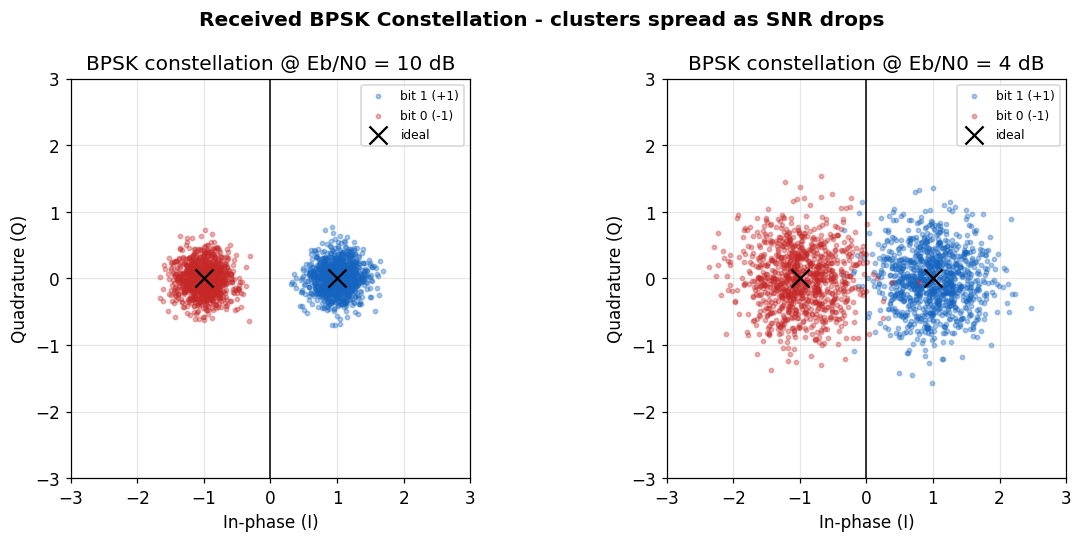

Saved -> figures/constellation.png


In [9]:
# --- BPSK constellation at two SNRs (baseband-equivalent complex model) ---
def bpsk_constellation(EbN0_dB, n=2000):
    b   = rng.integers(0, 2, n)
    sym = 2*b - 1                                  # +/-1 on the I axis
    EbN0 = 10**(EbN0_dB/10)
    sigma = np.sqrt(1/(2*EbN0))                    # noise std per dimension (Eb = 1)
    r = sym + sigma*rng.standard_normal(n) + 1j*sigma*rng.standard_normal(n)
    return b, r

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, snr in zip(axes, [10, 4]):
    b, r = bpsk_constellation(snr)
    ax.scatter(r[b==1].real, r[b==1].imag, s=8, alpha=0.35, color="#1565C0", label="bit 1 (+1)")
    ax.scatter(r[b==0].real, r[b==0].imag, s=8, alpha=0.35, color="#C62828", label="bit 0 (-1)")
    ax.scatter([-1, 1], [0, 0], marker="x", s=140, color="black", zorder=5, label="ideal")
    ax.axvline(0, color="k", lw=1)                 # decision boundary
    ax.set_title(f"BPSK constellation @ Eb/N0 = {snr} dB")
    ax.set_xlabel("In-phase (I)"); ax.set_ylabel("Quadrature (Q)")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("Received BPSK Constellation - clusters spread as SNR drops", fontweight="bold")
fig.tight_layout()
fig.savefig("figures/constellation.png", bbox_inches="tight")
plt.show()
print("Saved -> figures/constellation.png")

Noise scatters the ideal points into two clouds. At **Eb/N0 = 10 dB** the clouds are tight and well separated (almost no errors). At **Eb/N0 = 4 dB** they spread toward the decision boundary at `I = 0`, and every point that crosses it is a **bit error**.

### Bit Error Rate vs Eb/N0
The BER curve is the headline performance metric (the "error rate" of Work 1 Q3). We sweep Eb/N0, simulate the BER over many bits, and overlay the exact BPSK theory `BER = ½·erfc(√(Eb/N0))`.

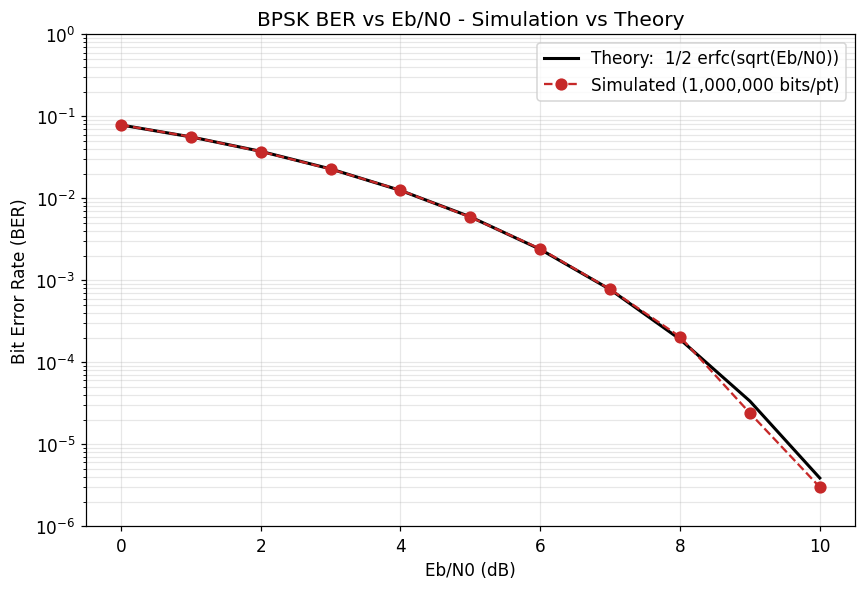

Eb/N0(dB)   sim BER     theory BER
    0      7.86e-02    7.86e-02
    1      5.64e-02    5.63e-02
    2      3.73e-02    3.75e-02
    3      2.28e-02    2.29e-02
    4      1.26e-02    1.25e-02
    5      5.90e-03    5.95e-03
    6      2.42e-03    2.39e-03
    7      7.78e-04    7.73e-04
    8      2.05e-04    1.91e-04
    9      2.40e-05    3.36e-05
   10      3.00e-06    3.87e-06
Saved -> figures/ber_curve.png


In [10]:
# --- Monte-Carlo BER vs Eb/N0, compared with BPSK theory ---
EbN0_dB = np.arange(0, 11)
n_bits  = 1_000_000
ber_sim = []
for dB in EbN0_dB:
    EbN0  = 10**(dB/10)
    sigma = np.sqrt(1/(2*EbN0))
    b     = rng.integers(0, 2, n_bits)
    s     = 2*b - 1
    r     = s + sigma*rng.standard_normal(n_bits)   # baseband BPSK + AWGN
    ber_sim.append(np.mean((r > 0).astype(int) != b))
ber_sim    = np.array(ber_sim)
ber_theory = 0.5*erfc(np.sqrt(10**(EbN0_dB/10)))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.semilogy(EbN0_dB, ber_theory, "k-",  lw=2,            label="Theory:  1/2 erfc(sqrt(Eb/N0))")
ax.semilogy(EbN0_dB, np.clip(ber_sim, 1e-7, None), "o--",
            color="#C62828", lw=1.5, ms=7,                label=f"Simulated ({n_bits:,} bits/pt)")
ax.set_xlabel("Eb/N0 (dB)"); ax.set_ylabel("Bit Error Rate (BER)")
ax.set_title("BPSK BER vs Eb/N0 - Simulation vs Theory")
ax.set_ylim(1e-6, 1); ax.grid(True, which="both", alpha=0.3); ax.legend()
fig.tight_layout()
fig.savefig("figures/ber_curve.png", bbox_inches="tight")
plt.show()

print("Eb/N0(dB)   sim BER     theory BER")
for dB, s, th in zip(EbN0_dB, ber_sim, ber_theory):
    print(f"   {dB:2d}      {s:.2e}    {th:.2e}")
print("Saved -> figures/ber_curve.png")

The simulated points track the theoretical curve almost exactly, confirming the implementation is correct. In this regime every extra **~1 dB of Eb/N0 roughly halves the error rate** — the steep "waterfall" that every digital link, including 5G, is engineered around.

---
## Conclusion
- Modeled a digital link as `Source → Modulator → Channel → Demodulator → Receiver`, both as a **Draw.io block diagram** (Part 1) and as a **working Python simulation** (Part 2).
- Implemented **BPSK over AWGN** end-to-end and visualized the signal at every node.
- Verified detection by recovering the transmitted bits and measuring **bit errors**, the **constellation**, and a **BER-vs-Eb/N0** curve that matches theory.

**Key takeaways**
1. Modulation = mapping bits onto a carrier (BPSK = 180° phase flips).
2. The channel is where noise enters; every block after it works to undo that damage.
3. Coherent demodulation + integrate-and-dump is the matched filter — optimal for BPSK in AWGN.
4. BER vs Eb/N0 is the universal yardstick, and the foundation that 5G's higher-order modulation and OFDM build on.

*This lab is the practical companion to Work 1 — Telecommunications Fundamentals: the transmitter–channel–receiver model and the analog-vs-digital / SNR / error-rate discussion there are realized here as runnable, measurable code.*